In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Genomic features

In [3]:
human_feat = pd.read_csv("../data/gencode.v48.basic.annotation.txt", sep = "\t", skiprows = list(range(5)), header = None)
human_feat.drop([1, 5, 7], axis = 1, inplace = True)
human_feat.columns = ["dname", "# feature", "start", "end", "strand", "gene_id", "gene_type", "gene_name"]
human_feat["start"] = human_feat["start"].astype(int)
human_feat["end"] = human_feat["end"].astype(int)
human_feat.head()

,dname,# feature,start,end,strand,gene_id,gene_type,gene_name
0,chr1,gene,28589,31109,+,ENSG00000243485.6,lncRNA,MIR1302-2HG
1,chr1,gene,30366,30503,+,ENSG00000284332.1,miRNA,MIR1302-2
2,chr1,gene,34553,37595,-,ENSG00000237613.3,lncRNA,FAM138A
3,chr1,gene,36526,40778,+,ENSG00000308361.1,lncRNA,ENSG00000308361
4,chr1,gene,51891,64116,+,ENSG00000290826.2,lncRNA,ENSG00000290826


In [4]:
human_genes = human_feat[(human_feat["gene_type"] == "  protein_coding") &
                         (human_feat["# feature"] == "transcript")]

In [5]:
mouse_feat = pd.read_csv("../data/GCF_000001635.27_GRCm39_feature_table.txt", sep = "\t")
mouse_feat.drop(["assembly_unit", "seq_type", "chromosome", "assembly", "product_accession", "non-redundant_refseq", "related_accession", "symbol", "locus_tag", "product_length", "attributes", "feature_interval_length"], axis = 1, inplace = True)
mouse_feat["start"] = mouse_feat["start"].astype(int)
mouse_feat["end"] = mouse_feat["end"].astype(int)
mouse_feat.dropna(subset=['name'], how='all', inplace=True)
mouse_feat.head()

/tmp/ipykernel_13965/341888760.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  mouse_feat = pd.read_csv("../data/GCF_000001635.27_GRCm39_feature_table.txt", sep = "\t")


,# feature,class,genomic_accession,start,end,strand,name,GeneID
0,gene,snRNA,NC_000067.7,3172239,3172348,+,"predicted gene, 26206",115487594
1,ncRNA,snRNA,NC_000067.7,3172239,3172348,+,U6 spliceosomal RNA,115487594
2,gene,protein_coding,NC_000067.7,3269956,3741733,-,X-linked Kx blood group related 4,497097
3,mRNA,NaN,NC_000067.7,3269956,3741733,-,"X-linked Kx blood group related 4, transcript ...",497097
4,mRNA,NaN,NC_000067.7,3284705,3741721,-,X-linked Kx blood group related 4,497097


## Split genomes

In [244]:
seg = pd.read_csv("human.A.1024.segments.txt", sep = "\t", header = None)
seg.columns = ["seg_id", "seq_id", "start", "seg_len"]
seg_copy = seg.copy()
seg.seq_id = seg.seq_id.str.split(";")
seg = seg.explode("seq_id")
seg = seg[seg["seq_id"] != ""]
seg = seg.astype({"seq_id" : "int64"})

seq = pd.read_csv("human.A.sequences.txt", sep = "\t", header = None)
seq.columns = ["name", "seq_id", "seq_len"]
seq.head()

,name,seq_id,seq_len
0,chr1,0,248956422
1,chr2,1,242193529
2,chr3,2,198295559
3,chr4,3,190214555
4,chr5,4,181538259


In [245]:
seg_copy[seg_copy["seg_id"] == 995]

,seg_id,seq_id,start,seg_len
995,995,342;114;38;95;180;214;377;64;43;244;376;310;63...,0,6349901


In [246]:
del seg_copy
seg[seg["seg_id"]== 995].head()

,seg_id,seq_id,start,seg_len
995,995,342,0,6349901
995,995,114,0,6349901
995,995,38,0,6349901
995,995,95,0,6349901
995,995,180,0,6349901


In [247]:
seg = df = pd.merge(seg, seq, on='seq_id', how='left')
seg.head()

,seg_id,seq_id,start,seg_len,name,seq_len
0,0,0,0,3233349,chr1,248956422
1,1,0,3233199,3233349,chr1,248956422
2,2,0,6466398,3233349,chr1,248956422
3,3,0,9699597,3233349,chr1,248956422
4,4,0,12932796,3233349,chr1,248956422


In [92]:
find_coverage = False
if find_coverage:
    df = human_genes.copy()
    df["len"] = df["end"] - df["start"]
    df = df.drop_duplicates(subset = ["gene_name"])

    gene_coverage = []
    exact_gene_coverage = []
    for index, row in seg.iterrows():
        seg_genes = df[(df["dname"] == row["name"]) &
                       (df["start"] >= row["start"]) &
                       (df["end"] <= row["start"] + row["seg_len"])]
        # quick and ignores overlapping genes
        gene_coverage.append(np.sum(seg_genes["len"]))

        # exact
        coverage = [0] * row["seg_len"]
        for index, row in seg_genes.iterrows():
            coverage[row["start"]:row["end"]] = [1] * (row["end"] - row["start"])
    
        exact_gene_coverage.append(coverage.count(1))

In [93]:
if find_coverage:
    seg["gene_coverage"] = gene_coverage
    seg["exact_gene_coverage"] = exact_gene_coverage
    seg.head()

## Plotting

In [432]:
XSMALL_SIZE = 10
SMALL_SIZE = 11
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

c_darkblue = CB_color_cycle[1]
c_darkgreen = CB_color_cycle[6]
c_purple = CB_color_cycle[7]

In [95]:
def bin_count_stats(df):
    print("min count\t" + str(np.min(df["count"])) + "\tbin\t" + str(df[df["count"] == np.min(df["count"])]["bin"].values[0]))
    print("max count\t" + str(np.max(df["count"])) + "\tbin\t" + str(df[df["count"] == np.max(df["count"])]["bin"].values[0]))
    print("mean count\t" + str(np.mean(df["count"])))
    print("stdev\t" + str(np.std(df["count"])))

In [435]:
def plot_bin_counts(filename):
    df = pd.read_csv(filename, header = None, names = ["shape", "window-size", "count", "seg-len"], sep = "\t")
    df["bin"] = np.arange(len(df["count"]))
    plt.figure(figsize=(8, 5))
    plt.bar(df["bin"], df["count"])
    plt.xlabel("Genome segment")
    plt.ylabel("Distinct minimiser count")
    plt.title("Distinct minimiser count across " + filename)
    bin_count_stats(df)

def get_header(filename):
    df = pd.read_csv(filename, header = None, names = ["shape", "window-size", "count", "seg-len"],  sep = "\t")
    return df

def plot_bin_entropy(df, outfile, titlename):
    df["bin"] = np.arange(len(df["count"]))
    plt.figure(figsize=(9, 5))
    color_list = []
    df["norm-count"] = df["count"] / df["seg-len"]
    mean_count = np.mean(df["norm-count"])

    high_entropy = mpatches.Patch(color=c_darkblue, label='high var')
    low_entropy = mpatches.Patch(color=c_darkgreen, label='low var')
    
    df['color'] = df['norm-count'].apply(lambda x: c_darkblue if x > mean_count else c_darkgreen) 
    #plt.ylim([0, 0.5])
    plt.bar(df["bin"], df["norm-count"], width=0.9, color = df["color"])
    plt.xlabel(titlename + " segment")
    plt.ylabel("Norm. distinct minimiser count")
    plt.title("Sequence variability characterised by gapped 23-mer counts.\n The information content of a k-mer match grows with variability.")
    plt.legend(handles=[high_entropy, low_entropy])
    plt.tight_layout()
    plt.savefig(outfile, dpi = 200)
    bin_count_stats(df)

c_peaks = CB_color_cycle[1] 
c_even = "gray"
c_odd = "lightgray"
def plot_repetitiveness(df, outfile, titlename):
    plt.figure(figsize=(8, 4))
    color_list = []
    df["rep"] = 1 - df["count"] / df["seg_len"]
    upper_quartile = rep_df.nlargest(round(1024/4), 'rep').sort_values(["rep"]).iloc[0]["rep"]
    perc90 = rep_df.nlargest(round(1024/10), 'rep').sort_values(["rep"]).iloc[0]["rep"]
    print(upper_quartile)
    high_label = mpatches.Patch(color=c_peaks, label='repet. segments')
    #low_label = mpatches.Patch(color=c_darkgreen, label='low rep')

    df['color'] = df['name'].apply(lambda x: c_even if x in even_names else c_odd) 
    df.loc[df['rep'] > upper_quartile, 'color'] = c_peaks
    #plt.ylim([0, 0.5])
    plt.xlim([-10, 1033])
    plt.ylim([0, 1.199])
    plt.ylabel("Local repetitiveness")
    
    no_duplicates = df[["bin", "rep", "color"]].drop_duplicates() 
    plt.bar(no_duplicates["bin"], no_duplicates["rep"], width=1.5, color = no_duplicates["color"])
    plt.xlabel(titlename + " segment")
    #plt.ylabel("Norm. distinct minimiser count")
    
    high_rep = rep_df[rep_df["rep"] > upper_quartile].copy().sort_values(["rep"], ascending = False)
    for name in np.unique(high_rep["name"]):
        row = high_rep[high_rep["name"] == name].iloc[0]
        if (not "_" in row["name"]):
            if (not "EBV" in row["name"]):
                #peak_label = str(row["bin"] + "\t" + row["name"]) + ":" + str(row["start"]) + "-" + str(row["start"] + row["seg_len"])
                peak_label = row["name"]
                x = row["bin"]
                y = row["rep"]
                if (row["name"] == "chr21"):
                    x = row["bin"] - 20
                if (row["name"] == "chr17"):
                    y = row["rep"] - 0.02
                    x = row["bin"] - 10
                    
                plt.text(x, y, peak_label, size = XSMALL_SIZE, rotation=45,
                             horizontalalignment="left", verticalalignment="center",
                             rotation_mode="anchor")

    #plt.arrow(2, 4, 2, 2, head_width=0.2, width=0.05, ec='green')
    plt.title("How many 19-mers have duplicates nearby?")
    #plt.legend(handles=[high_label], loc = "lower right")
    plt.tight_layout()
    plt.savefig(outfile, dpi = 200)
    bin_count_stats(df)

In [97]:
filename = "bin_entropy/mouse.k17.header"
df = get_header(filename)
df["bin"] = np.arange(len(df["count"]))
no_matches = df[(df["bin"] >= 989) & (df["bin"] <= 1022)]

In [98]:
np.mean(no_matches["count"] / no_matches["seg-len"])

0.3247826222959495

## Are segments of equal length?

No

In [99]:
filename = "human.A.unmasked.header"
df = get_header(filename)
np.std(df["seg-len"])

515163.33993354347

Is normalization necessary?

In [100]:
df["entropy"] = df["count"] / df["seg-len"]
round(df["count"].corr(df["entropy"]), 3)

0.851

Yes, to describe 13% of the variation

## Plot repetitiveness across the genome

In [349]:
#chr_names = [name for name in np.unique(rep_df["name"]) if not any(char in name for char in ["_", "EBV", "M"])]
chr_names = ['chr1',
 'chr2',
 'chr3',
 'chr4',
 'chr5',
 'chr6',
 'chr7',
 'chr8',
 'chr9',
 'chr10',
 'chr11',
 'chr12',
 'chr13',
 'chr14',
 'chr15',
 'chr16',
 'chr17',
 'chr18',
 'chr19',
 'chr20',
 'chr21',
 'chr22',
 'chrX',
 'chrY']

even_names = [chr_names[idx] for idx in range(0, len(chr_names), 2)]
even_names

['chr1',
 'chr3',
 'chr5',
 'chr7',
 'chr9',
 'chr11',
 'chr13',
 'chr15',
 'chr17',
 'chr19',
 'chr21',
 'chrX']

In [350]:
rep_df = get_header("human.A.1024.min1.k19.header")
rep_df["bin"] = np.arange(len(rep_df["count"]))
rep_df = rep_df.set_index('bin').join(seg.set_index('seg_id')).drop(["seg-len"], axis = 1)
rep_df["bin"] = rep_df.index
rep_df.head()

,shape,window-size,count,seq_id,start,seg_len,name,seq_len,bin
0,1111111111111111111,21,1151625,0,0,3233349,chr1,248956422,0
1,1111111111111111111,21,1480699,0,3233199,3233349,chr1,248956422,1
2,1111111111111111111,21,1385521,0,6466398,3233349,chr1,248956422,2
3,1111111111111111111,21,1352394,0,9699597,3233349,chr1,248956422,3
4,1111111111111111111,21,1302899,0,12932796,3233349,chr1,248956422,4


In [352]:
rep_df = df = pd.read_csv("human.k19.kmc.header", header = None, names = ["shape", "window-size", "bin", "count"],  sep = "\t")
rep_df = rep_df.set_index('bin').join(seg.set_index('seg_id'))
rep_df["bin"] = rep_df.index
rep_df.head()

,shape,window-size,count,seq_id,start,seg_len,name,seq_len,bin
0,1111111111111111111,19,2370969,0,0,3233349,chr1,248956422,0
1,1111111111111111111,19,3040816,0,3233199,3233349,chr1,248956422,1
2,1111111111111111111,19,2838727,0,6466398,3233349,chr1,248956422,2
3,1111111111111111111,19,2768735,0,9699597,3233349,chr1,248956422,3
4,1111111111111111111,19,2665661,0,12932796,3233349,chr1,248956422,4


0.2801563484005295
min count	1	bin	39
max count	17579504	bin	964
mean count	4342804.023054755
stdev	4336931.154669709


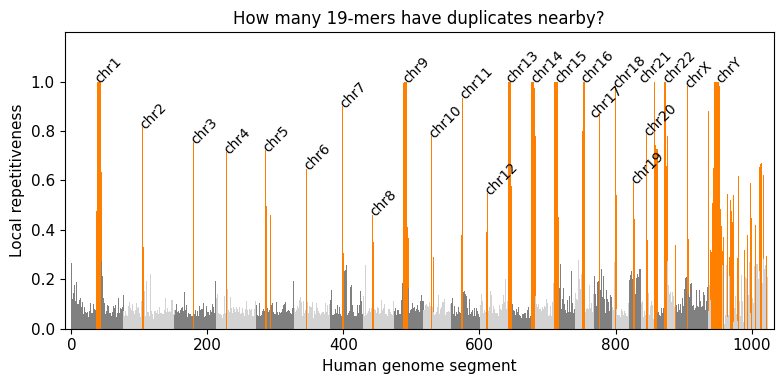

In [436]:
plot_repetitiveness(rep_df, "human.k19.rep.svg", "Human genome")

In [262]:
print("chr\tstart\tend\trep")
for index, row in rep_df[rep_df["rep"] > 0.8].iterrows():
    row_seg = seg[seg["seg_id"] == row["bin"]].iloc[0]
    if (not "_" in row_seg["name"]):
        print(str(row_seg["name"]) + ":" + str(row_seg["start"]) + "-" + str(row_seg["start"] + row_seg["seg_len"]) + "\t" + str(row["rep"]))

chr	start	end	rep
chr1:122861562-126094911	0.95807783199401
chr1:126094761-129328110	0.9999996907231481
chr1:129327960-132561309	0.9999996907231481
chr1:132561159-135794508	0.9999996907231481
chr1:135794358-139027707	0.9999996907231481
chr1:139027557-142260906	0.9999996907231481
chr1:142260756-145494105	0.8200834490801951
chr2:90418888-93648284	0.9095378826257294
chr3:91020860-94271755	0.8801219356515667
chr4:48359610-51583734	0.8598859721276229
chr5:45384528-48626430	0.8642824490067867
chr6:58009536-61232438	0.8269727096883492
chr7:58535208-61787314	0.9504016781740816
chr9:45058706-48277335	0.9961769436614161
chr9:48277185-51495814	0.9999996893087088
chr9:51495664-54714293	0.9999996893087088
chr9:54714143-57932772	0.9999996893087088
chr9:57932622-61151251	0.9553754098406495
chr10:39160176-42423674	0.8903477189200055
chr11:51461520-54678015	0.9679638861555824
chr13:0-3267698	0.9999996939741678
chr13:3267548-6535246	0.9999996939741678
chr13:6535096-9802794	0.9999996939741678
chr13:98026

## Plot entropy across the genome

The number of distinct minimisers is a proxy for the entropy

In [39]:
all_df = get_header("human.A.max50.header")

In [40]:
all_df["norm-count"] = all_df["count"] / all_df["seg-len"]
all_df.head()

,shape,window-size,count,seg-len,norm-count
0,11111010010100110111111,25,162255,824459,0.196802
1,11111010010100110111111,25,349076,824459,0.423400
2,11111010010100110111111,25,347479,824459,0.421463
3,11111010010100110111111,25,332668,824459,0.403499
4,11111010010100110111111,25,377995,824459,0.458476


In [18]:
np.mean(all_df["norm-count"])

0.419384713082309

In [19]:
np.max(all_df["norm-count"])

0.48437861160335927

In [41]:
unique_df = all_df.copy()
unique_df["count"] = all_df["count"] - rep_df["count"]
unique_df.head()

,shape,window-size,count,seg-len,norm-count
0,11111010010100110111111,25,64267,824459,0.196802
1,11111010010100110111111,25,331162,824459,0.423400
2,11111010010100110111111,25,328764,824459,0.421463
3,11111010010100110111111,25,321798,824459,0.403499
4,11111010010100110111111,25,370771,824459,0.458476


min count	0	bin	152
max count	460180	bin	3874
mean count	319006.2893066406
stdev	110971.51639950853


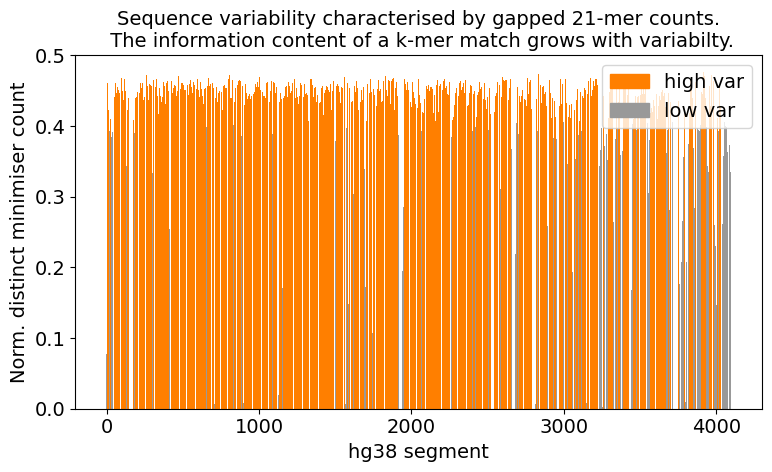

In [19]:
plot_bin_entropy(unique_df, "human.gapped.23.unique.entropy.png", "hg38")

min count	1	bin	152
max count	489873	bin	3874
mean count	328797.1916503906
stdev	111310.39968236521


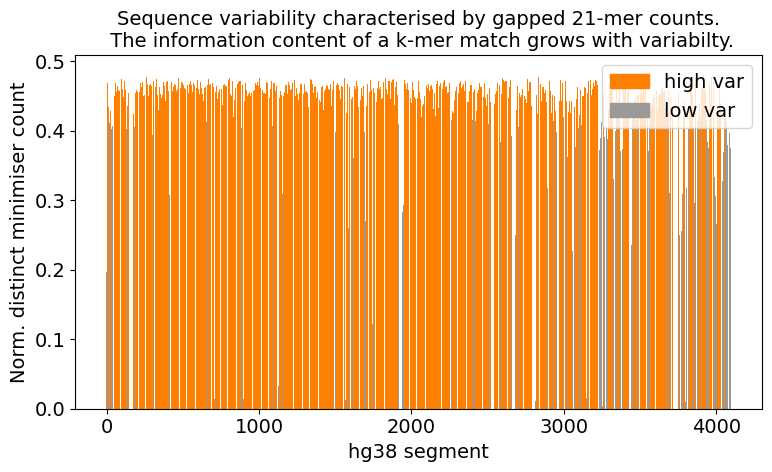

In [55]:
df = get_header("human.A.max254.header")
plot_bin_entropy(df, "human.gapped.23.max254.entropy.png", "hg38")

min count	0	bin	152
max count	489862	bin	3874
mean count	328747.1025390625
stdev	111352.11762450525


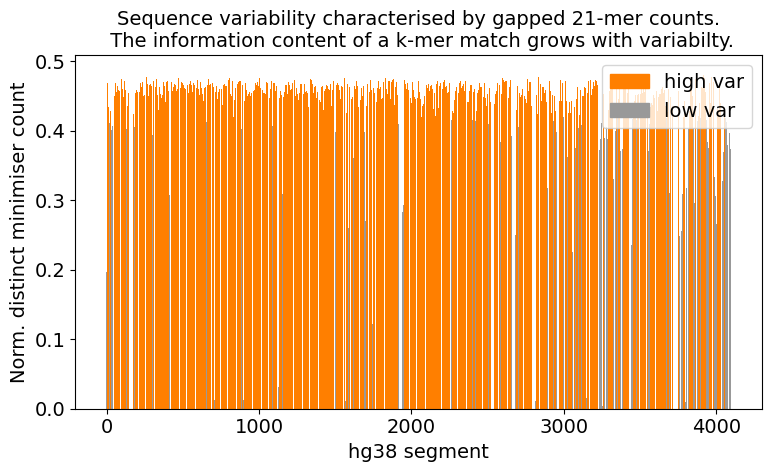

In [58]:
human_df = get_header("human.A.max50.header")
plot_bin_entropy(human_df, "human.gapped.23.max50.entropy.png", "hg38")

min count	0	bin	152
max count	489862	bin	3874
mean count	328747.1025390625
stdev	111352.11762450525


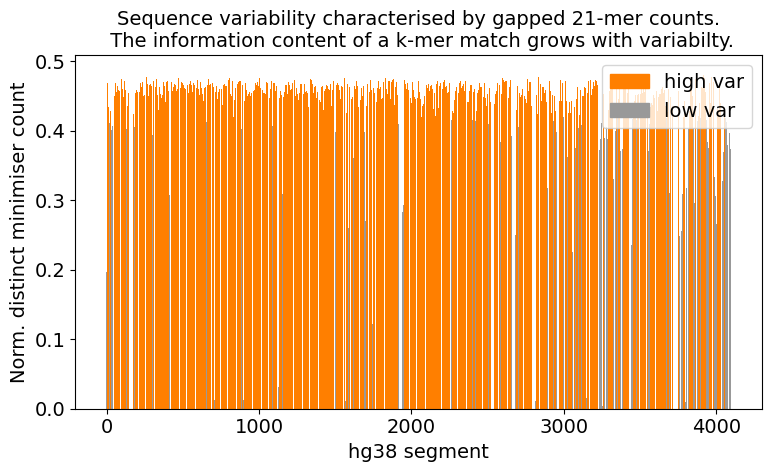

In [57]:
human_df = get_header("human.A.min1.header")
plot_bin_entropy(human_df, "human.gapped.23.min1.entropy.png", "hg38")

min count	0	bin	152
max count	165565	bin	2817
mean count	9740.813232421875
stdev	9623.030663944164


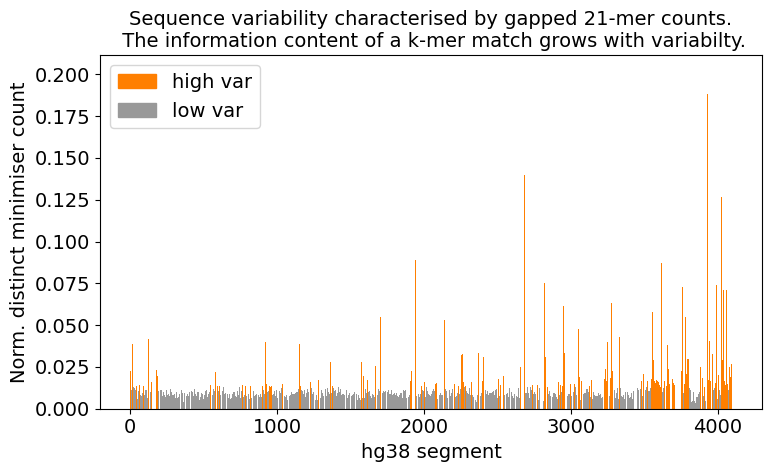

In [15]:
human_df = plot_bin_entropy("human.A.min2.header", "human.gapped.23.min2.entropy.png", "hg38")

min count	3504	bin	38
max count	186966	bin	1
mean count	43702.84375
stdev	57842.58461797922


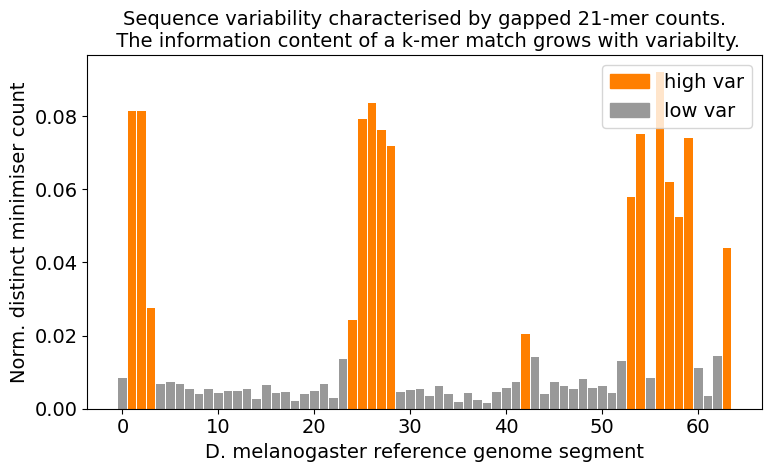

In [18]:
plot_bin_entropy("fly.header", "fly.entropy.png", "D. melanogaster reference genome")